In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset
from transformers import BertTokenizer
from dev.dynamic_dataloader import CustomDataLoader
from dev.early_stopper import EarlyStopping
import math

np.random.seed(42)

/Users/mahas/PycharmProjects/STIRS/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Setting up Parameters and Loading Data

In [2]:
# Setting up the parameters
maximum_features = 30522  # Vocabulary size for BERT
maximum_length = 256  # Max length of input sequences
word_embedding_dims = 50  # Dimension of word embeddings (Note: In PyTorch this is embedding_dim)
no_of_filters = 64  # Number of filters for Conv1D
kernel_size = 3  # Size of the convolutional kernel
hidden_dim_1 = 64  # Neurons in the dense hidden layer

gamma = 0.2

batch_size = 64
epochs = 20
threshold = 0.5
DATASET_SIZE = 100_000


In [3]:
df = pd.read_csv("imdb_dataset.csv")

df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    df.review, df.sentiment, test_size=0.2, random_state=42, shuffle=True
)

In [4]:
df['sentiment'].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

### 3. Tokenization and Data Preparation
Here, we tokenize the text with the BERT tokenizer but set `return_tensors='pt'` for PyTorch tensors. We then create `TensorDataset` and `DataLoader` objects to handle batching.

In [5]:
# Tokenize and encode the data using the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

# Encode the training and test data
X_train_encoded = tokenizer.batch_encode_plus(
    x_train.tolist(),
    padding='max_length',
    truncation=True,
    max_length=maximum_length,
    add_special_tokens=True,
    return_tensors='pt',  # Return PyTorch tensors
)

X_test_encoded = tokenizer.batch_encode_plus(
    x_test.tolist(),
    padding='max_length',
    truncation=True,
    max_length=maximum_length,
    add_special_tokens=True,
    return_tensors='pt',  # Return PyTorch tensors
)

# Create PyTorch Datasets
train_dataset = TensorDataset(X_train_encoded['input_ids'], torch.tensor(y_train.values, dtype=torch.float32))
test_dataset = TensorDataset(X_test_encoded['input_ids'], torch.tensor(y_test.values, dtype=torch.float32))

# Create DataLoaders
train_loader = CustomDataLoader(train_dataset, batch_size=batch_size, gamma=gamma)
test_loader = CustomDataLoader(test_dataset, batch_size=batch_size, gamma=gamma)

### 4. Building the PyTorch Model

We define the CNN architecture as a class inheriting from `torch.nn.Module`. Note the use of `.permute(0, 2, 1)` to make the tensor shape compatible with `nn.Conv1d`.

In [13]:
class CNNTextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_filters, filter_size, hidden_dim):
        super(CNNTextClassifier, self).__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Convolutional layers
        self.conv1 = nn.Conv1d(embedding_dim, n_filters, kernel_size=filter_size, padding='valid')
        self.pool1 = nn.MaxPool1d(kernel_size=3)

        self.conv2 = nn.Conv1d(n_filters, n_filters, kernel_size=filter_size, padding='valid')
        self.pool2 = nn.MaxPool1d(kernel_size=3)

        self.conv3 = nn.Conv1d(n_filters, n_filters, kernel_size=filter_size, padding='valid')
        # Global Max Pooling is achieved with AdaptiveMaxPool1d
        self.global_pool = nn.AdaptiveMaxPool1d(1)

        # Dense layers
        self.fc1 = nn.Linear(n_filters, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, input_ids):
        # input_ids shape: (batch_size, seq_len)
        embedded = self.embedding(input_ids)
        # embedded shape: (batch_size, seq_len, embedding_dim)

        # PyTorch Conv1d expects (batch_size, channels, seq_len)
        # So we permute the dimensions
        embedded = embedded.permute(0, 2, 1)

        x = self.pool1(F.relu(self.conv1(embedded)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = F.relu(self.conv3(x))

        x = self.global_pool(x).squeeze(2)  # Squeeze to remove the last dimension

        x = F.relu(self.fc1(x))
        output = torch.sigmoid(self.fc2(x))

        return output


# Instantiate the model
model = CNNTextClassifier(
    vocab_size=maximum_features,
    embedding_dim=word_embedding_dims,
    n_filters=no_of_filters,
    filter_size=kernel_size,
    hidden_dim=hidden_dim_1
)

# Set device (use GPU if available)
device = torch.device("mps" if torch.mps.is_available() else "cpu")
model.to(device)

CNNTextClassifier(
  (embedding): Embedding(30522, 50)
  (conv1): Conv1d(50, 64, kernel_size=(3,), stride=(1,), padding=valid)
  (pool1): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=valid)
  (pool2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=valid)
  (global_pool): AdaptiveMaxPool1d(output_size=1)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

### 5. Training the Model

We define the loss function and optimizer, then write an explicit loop to train the model over 10 epochs and validate its performance.

In [14]:
# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.AdamW(model.parameters())

early_stopping = EarlyStopping()

# To store history
history = {
    'loss': [],
    'val_loss': [],
    'accuracy': [],
    'val_accuracy': []
}

best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    total_loss = 0
    correct_train = 0
    total_train = 0



    dynamic = True if epoch % 2 != 0 else False
    # print("Dynamic:", dynamic)
    times = 1
    if dynamic:
        times = math.ceil(1 / gamma)
    # print("Running", times, "times in this epoch")
    for _ in range(times):
        # do this batch loop how many ever times it needs
        # this will run 5 times, if its an even epoch, and gamma = 0.2
        batch_losses = {}
        for batch_id, (input_ids, labels) in train_loader.generate(dynamic=dynamic):
            # print(batch_id)
            input_ids, labels = input_ids.to(device), labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(input_ids)
            loss = criterion(outputs, labels)

            batch_losses[batch_id] = loss.item()

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            predicted = (outputs > threshold).int()
            total_train += labels.size(0)
            correct_train += (predicted == labels.int()).sum().item()
        train_loader.update_losses(batch_losses)

    avg_train_loss = total_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    # --- Validation Phase ---
    model.eval()
    total_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch_id, (input_ids, labels) in test_loader.generate():
            input_ids, labels = input_ids.to(device), labels.to(device).unsqueeze(1)
            outputs = model(input_ids)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()

            predicted = (outputs > threshold).int()
            total_val += labels.size(0)
            correct_val += (predicted == labels.int()).sum().item()

    avg_val_loss = total_val_loss / len(test_loader)
    val_accuracy = correct_val / total_val

    # Save history
    history['loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['accuracy'].append(train_accuracy)
    history['val_accuracy'].append(val_accuracy)

    # Save the best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())

    print(f"{'Dyn' if dynamic else 'Nor'} Epoch {epoch + 1}/{epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}")

    if early_stopping.record(avg_val_loss, window=5):
        print('Early Stopping')
        break

# Load best model weights
model.load_state_dict(best_model_wts)

Nor Epoch 1/20 | Train Loss: 0.6182 | Train Acc: 0.6167 | Val Loss: 0.4692 | Val Acc: 0.7739
Dyn Epoch 2/20 | Train Loss: 0.3936 | Train Acc: 0.8208 | Val Loss: 0.3613 | Val Acc: 0.8389
Nor Epoch 3/20 | Train Loss: 0.2895 | Train Acc: 0.8780 | Val Loss: 0.3466 | Val Acc: 0.8487
Dyn Epoch 4/20 | Train Loss: 0.2426 | Train Acc: 0.9044 | Val Loss: 0.3402 | Val Acc: 0.8575
Nor Epoch 5/20 | Train Loss: 0.1751 | Train Acc: 0.9331 | Val Loss: 0.3685 | Val Acc: 0.8559
Dyn Epoch 6/20 | Train Loss: 0.1325 | Train Acc: 0.9547 | Val Loss: 0.4223 | Val Acc: 0.8525
Nor Epoch 7/20 | Train Loss: 0.1036 | Train Acc: 0.9629 | Val Loss: 0.4335 | Val Acc: 0.8594
Dyn Epoch 8/20 | Train Loss: 0.0679 | Train Acc: 0.9788 | Val Loss: 0.5747 | Val Acc: 0.8436
Nor Epoch 9/20 | Train Loss: 0.0737 | Train Acc: 0.9717 | Val Loss: 0.5127 | Val Acc: 0.8561
Dyn Epoch 10/20 | Train Loss: 0.0327 | Train Acc: 0.9895 | Val Loss: 0.7006 | Val Acc: 0.8526
Nor Epoch 11/20 | Train Loss: 0.0561 | Train Acc: 0.9785 | Val Loss: 

<All keys matched successfully>

### 6. Evaluating the Model

In [15]:
model.eval()
y_pred_prob = []
y_true = []

with torch.no_grad():
    for batch_id, (input_ids, labels) in test_loader.generate():
        input_ids = input_ids.to(device)
        outputs = model(input_ids).squeeze()
        y_pred_prob.extend(outputs.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

y_pred = (np.array(y_pred_prob) > threshold).astype(int)

# Calculating and printing evaluation metrics
print('\nEvaluation Metrics:')
print('Accuracy:', accuracy_score(y_true, y_pred))
print('Precision:', precision_score(y_true, y_pred))
print('Recall:', recall_score(y_true, y_pred))
print('F1-score:', f1_score(y_true, y_pred))
print('\nClassification Report:')
print(classification_report(y_true, y_pred))


Evaluation Metrics:
Accuracy: 0.8575
Precision: 0.8400451637184795
Recall: 0.8858900575511014
F1-score: 0.8623587365980875

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.83      0.85      4961
         1.0       0.84      0.89      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



### 7. Plotting Results

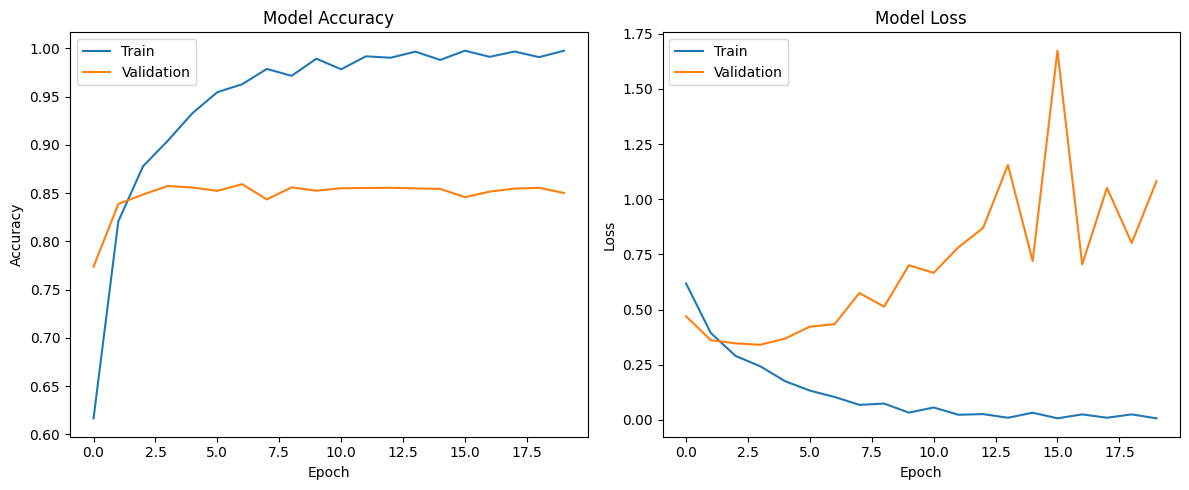

In [16]:
# Plotting Model Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["accuracy"])
plt.plot(history["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")

# Plotting Model Loss
plt.subplot(1, 2, 2)
plt.plot(history["loss"])
plt.plot(history["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")

plt.tight_layout()
plt.show()

### 8. Saving the Model

Finally, we can save the trained model's state dictionary for later use.

In [17]:
dic = train_loader.get_batch_counts()
keys = list(dic.keys())
keys.sort(key=lambda x: dic[x], reverse=True)
print("Most Frequent Keys:")
for i in keys[:5]:
    print(i, dic[i])
print("Least Frequent Keys:")
for i in keys[-5:]:
    print(i, dic[i])

Most Frequent Keys:
2560 51
32960 47
24192 41
3072 40
19648 40
Least Frequent Keys:
35136 18
38784 18
39360 18
7104 17
24768 17


(array([ 29., 136., 274., 114.,  48.,  16.,   5.,   1.,   1.,   1.]),
 array([17. , 20.4, 23.8, 27.2, 30.6, 34. , 37.4, 40.8, 44.2, 47.6, 51. ]),
 <BarContainer object of 10 artists>)

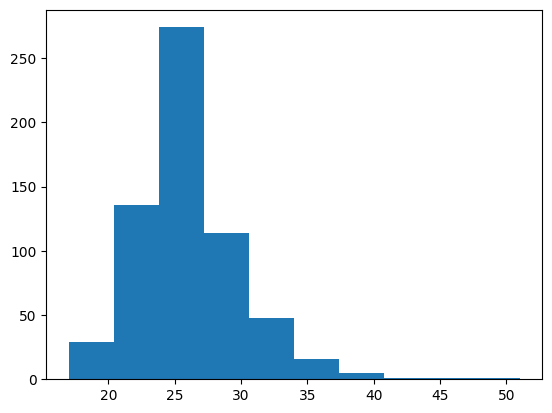

In [18]:
values = list(dic.values())
plt.hist(values)

In [19]:
keys[0]

2560

In [20]:
train_loader._batches[keys[0]]

(tensor([[  101,  1012,  1012,  ...,  2023, 28616,   102],
         [  101,  3113,  2848,  ...,  2008,  2023,   102],
         [  101, 26316,  1010,  ...,  2310, 10657,   102],
         ...,
         [  101,  1999,  2563,  ...,     0,     0,     0],
         [  101,  1045,  2001,  ...,  2301,  2044,   102],
         [  101,  1045,  2245,  ...,     0,     0,     0]]),
 tensor([0., 0., 1., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0.,
         1., 1., 1., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 0., 1.,
         1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1.,
         0., 0., 1., 0., 0., 1., 0., 1., 0., 1.]))